# 09 - Support Vector Machines

This notebook studies SVMs through a custom binary soft-margin implementation and sklearn references. EnergyTypeNet remains the main dataset; synthetic 2D data is used only for clean margin and kernel visualizations.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs, make_moons
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, SVR

from src.models import LogisticRegressionOvR, SVMClassifierCustom

plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_STATE = 42

## 1. Maximum-Margin Idea

A linear SVM searches for a separating hyperplane with the widest margin. Points inside the margin or on the wrong side pay hinge loss. The soft-margin parameter `C` controls the tradeoff between margin width and classification errors.

,model,accuracy,support_vectors
0,Custom linear SVM,1.0,22
1,sklearn linear SVM,1.0,4


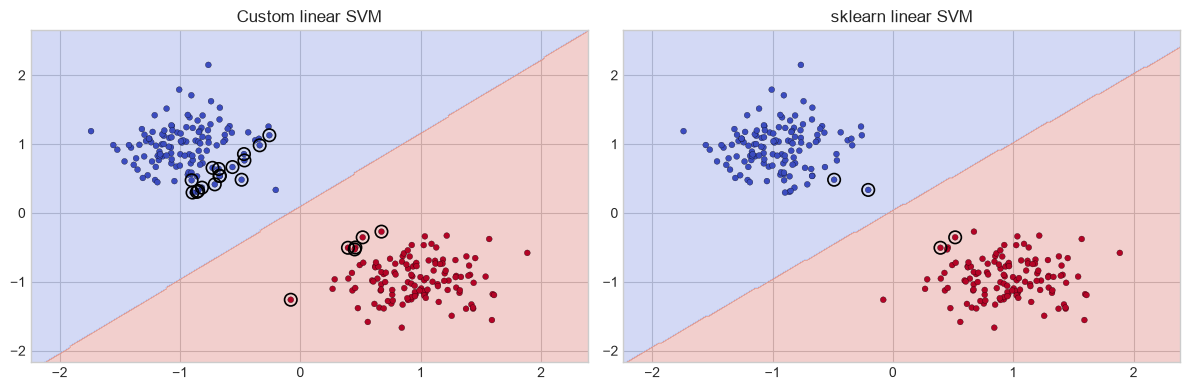

In [2]:
X_sep, y_sep = make_blobs(n_samples=250, centers=2, cluster_std=1.2, random_state=RANDOM_STATE)
X_sep = StandardScaler().fit_transform(X_sep)

custom_svm = SVMClassifierCustom(C=1.0, learning_rate=0.01, n_iterations=1500, kernel='linear').fit(X_sep, y_sep)
sklearn_svm = SVC(kernel='linear', C=1.0).fit(X_sep, y_sep)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

def plot_boundary(ax, model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c=y, s=18, cmap='coolwarm', edgecolor='k', linewidth=0.2)
    if hasattr(model, 'support_vectors_') and len(model.support_vectors_) > 0:
        sv = model.support_vectors_
        ax.scatter(sv[:, 0], sv[:, 1], s=80, facecolors='none', edgecolors='black', linewidths=1.2)
    ax.set_title(title)

plot_boundary(axes[0], custom_svm, X_sep, y_sep, 'Custom linear SVM')
plot_boundary(axes[1], sklearn_svm, X_sep, y_sep, 'sklearn linear SVM')
plt.tight_layout()

pd.DataFrame([
    {'model': 'Custom linear SVM', 'accuracy': accuracy_score(y_sep, custom_svm.predict(X_sep)), 'support_vectors': len(custom_svm.support_vectors_)},
    {'model': 'sklearn linear SVM', 'accuracy': accuracy_score(y_sep, sklearn_svm.predict(X_sep)), 'support_vectors': len(sklearn_svm.support_vectors_)},
])

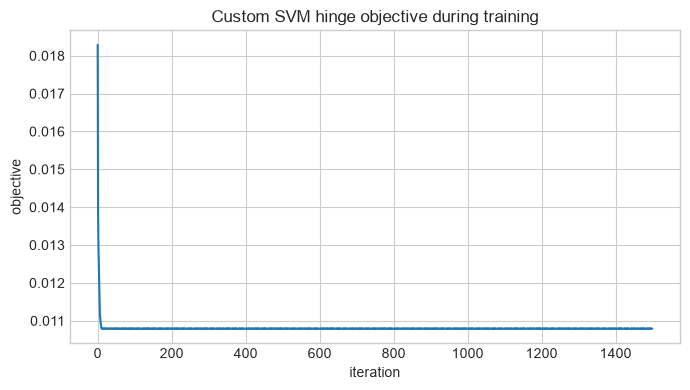

In [3]:
plt.figure(figsize=(7, 4))
plt.plot(custom_svm.loss_history_)
plt.title('Custom SVM hinge objective during training')
plt.xlabel('iteration')
plt.ylabel('objective')
plt.tight_layout()

## 2. Binary EnergyTypeNet Classification

The binary task is Residential vs all other building types. This keeps the custom SVM aligned with its binary formulation while still using the project dataset.

In [4]:
train_df = pd.read_csv(ROOT / 'data' / 'train_energy_data.csv').dropna()
test_df = pd.read_csv(ROOT / 'data' / 'test_energy_data.csv').dropna()

feature_cols = ['Energy Consumption', 'Square Footage', 'Number of Occupants', 'Appliances Used', 'Average Temperature']
X_train = train_df[feature_cols].to_numpy(float)
X_test = test_df[feature_cols].to_numpy(float)
y_train = (train_df['Building Type'] == 'Residential').astype(int).to_numpy()
y_test = (test_df['Building Type'] == 'Residential').astype(int).to_numpy()

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

custom_energy_svm = SVMClassifierCustom(C=1.0, learning_rate=0.001, n_iterations=2500, kernel='linear').fit(X_train_s, y_train)
sklearn_energy_svm = SVC(kernel='linear', C=1.0).fit(X_train_s, y_train)
logreg_ovr = LogisticRegressionOvR(eta=0.05, n_iter=1000, alpha=0.001, random_state=RANDOM_STATE).fit(X_train_s, y_train)

binary_results = []
for name, model in [('Custom linear SVM', custom_energy_svm), ('sklearn linear SVM', sklearn_energy_svm), ('Custom logistic OvR', logreg_ovr)]:
    pred = model.predict(X_test_s)
    binary_results.append({'model': name, 'test_accuracy': accuracy_score(y_test, pred), 'test_f1': f1_score(y_test, pred)})

pd.DataFrame(binary_results)

,model,test_accuracy,test_f1
0,Custom linear SVM,1.0,1.0
1,sklearn linear SVM,1.0,1.0
2,Custom logistic OvR,1.0,1.0


## 3. Kernel Comparison on Nonlinear Data

The moons dataset is used only to make the kernel idea visible. Linear SVMs draw straight boundaries; RBF kernels can model curved boundaries.

,model,accuracy
0,Linear SVM,0.846
1,Polynomial SVM,0.848
2,RBF SVM,0.950
3,Custom RBF-feature SVM,0.946


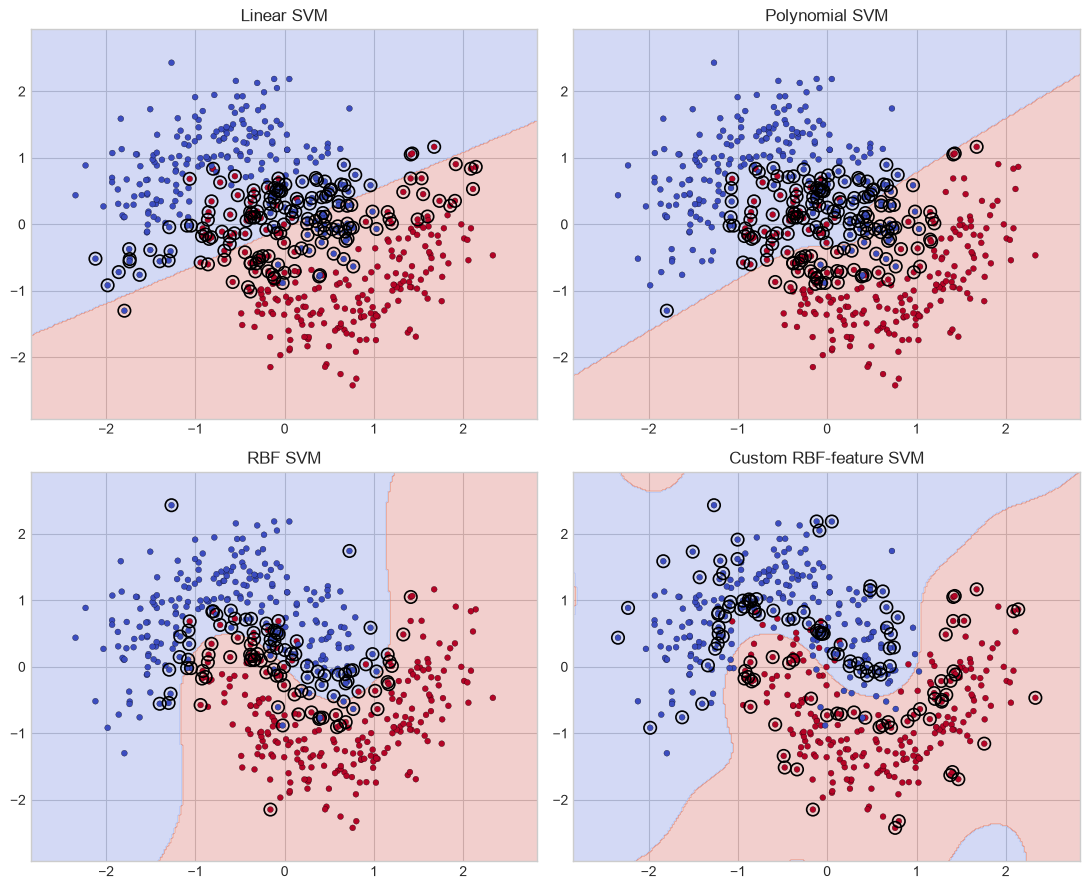

In [5]:
X_moons, y_moons = make_moons(n_samples=500, noise=0.25, random_state=RANDOM_STATE)
X_moons = StandardScaler().fit_transform(X_moons)

models = [
    ('Linear SVM', SVC(kernel='linear', C=1.0)),
    ('Polynomial SVM', SVC(kernel='poly', degree=3, C=1.0, gamma='scale')), 
    ('RBF SVM', SVC(kernel='rbf', C=2.0, gamma='scale')),
    ('Custom RBF-feature SVM', SVMClassifierCustom(C=1.0, learning_rate=0.01, n_iterations=1500, kernel='rbf', gamma=1.0, n_components=300, random_state=RANDOM_STATE)),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
kernel_rows = []
for ax, (name, model) in zip(axes.ravel(), models):
    model.fit(X_moons, y_moons)
    plot_boundary(ax, model, X_moons, y_moons, name)
    kernel_rows.append({'model': name, 'accuracy': accuracy_score(y_moons, model.predict(X_moons))})
plt.tight_layout()

pd.DataFrame(kernel_rows)

## 4. Hyperparameter Search

For sklearn SVC, `C` controls soft-margin strength and `gamma` controls RBF locality. Grid search makes the bias-variance tradeoff explicit.

In [6]:
svc_grid = GridSearchCV(
    SVC(kernel='rbf'),
    param_grid={'C': [0.1, 1.0, 10.0], 'gamma': ['scale', 0.1, 1.0]},
    cv=3,
    scoring='accuracy',
)
svc_grid.fit(X_train_s, y_train)

pd.DataFrame(svc_grid.cv_results_)[['param_C', 'param_gamma', 'mean_test_score', 'rank_test_score']].sort_values('rank_test_score').head(8)

,param_C,param_gamma,mean_test_score,rank_test_score
3,1.0,scale,1.000000,1
7,10.0,0.1,1.000000,1
6,10.0,scale,1.000000,1
4,1.0,0.1,1.000000,1
8,10.0,1.0,0.979992,5
5,1.0,1.0,0.949992,6
0,0.1,scale,0.676023,7
1,0.1,0.1,0.665012,8


## 5. SVM Regression on Energy Consumption

SVMs can also do regression through SVR. This section predicts energy consumption from the other numeric building attributes.

In [7]:
reg_features = ['Square Footage', 'Number of Occupants', 'Appliances Used', 'Average Temperature']
Xr = train_df[reg_features].to_numpy(float)
yr = train_df['Energy Consumption'].to_numpy(float)

svr_models = [
    ('Linear SVR', make_pipeline(StandardScaler(), SVR(kernel='linear', C=1.0))),
    ('RBF SVR', make_pipeline(StandardScaler(), SVR(kernel='rbf', C=10.0, gamma='scale'))),
]

svr_rows = []
for name, model in svr_models:
    scores = cross_val_score(model, Xr, yr, cv=5, scoring='r2')
    svr_rows.append({'model': name, 'cv_r2_mean': scores.mean(), 'cv_r2_std': scores.std()})

pd.DataFrame(svr_rows)

,model,cv_r2_mean,cv_r2_std
0,Linear SVR,0.619575,0.019841
1,RBF SVR,0.535637,0.009721


## 6. Summary

| Algorithm | Dataset | Task | Custom? | Metric | Notes |
| --- | --- | --- | --- | --- | --- |
| SVMClassifierCustom linear | EnergyTypeNet | Residential vs rest | Yes | Accuracy / F1 | Soft-margin hinge-loss model |
| SVMClassifierCustom RBF features | make_moons | Nonlinear classification | Yes | Accuracy | Uses random Fourier features for RBF approximation |
| sklearn SVC linear/RBF/poly | make_moons + EnergyTypeNet | Classification | No | Accuracy | Reference kernel implementations |
| sklearn SVR | EnergyTypeNet | Energy consumption regression | No | CV R2 | Regression extension of SVMs |

Key takeaways:
- The EnergyTypeNet binary task is highly separable, so perfect binary SVM accuracy should be read as a margin demonstration rather than the full multiclass result.
- On the nonlinear moons data, the RBF kernel clearly outperforms the linear model, showing why kernels matter when the decision boundary is curved.
- The custom SVM exposes hinge loss, margins, and support vectors, while sklearn remains the stronger production implementation.
- For energy-consumption regression, Linear SVR performs better than RBF SVR here, suggesting the selected numeric features are mostly linear for this regression target.
